<a href="https://colab.research.google.com/github/fishpenyet/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, img_as_float
from scipy.ndimage import gaussian_filter
import os

In [ ]:
os.makedirs("images/output", exist_ok = True)
os.makedirs("images/input", exist_ok = True)

In [ ]:
def show_images(titles, images, figsize=(15, 5), cmap='gray'):
  plt.figure(figsize=figsize)
  for i, (title, img) in enumerate(zip(titles, images)):
    plt.subplot(1, len(images), i + 1)
    if len(img.shape)==2:
      plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    else:
      plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
def enhance_dark_image(img, clup_limit=3.0, title_grid=(4,4), gamma=1.5, saturation=1.9):
  lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
  l, a, b = cv2.split(lab)

  clahe = cv2.createCLAHE(clipLimit=clup_limit, tileGridSize=title_grid)
  l_clahe = clahe.apply(l)
  lab_clahe = cv2.merge((l_clahe, a, b))
  img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

  inv_gamma = 1.0 / gamma
  table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
  img_gamma = cv2.LUT(img_clahe, table)

  if saturation != 1:
        hsv = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * saturation, 0, 255)
        img_gamma = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

  return img_gamma

In [ ]:
def enhance_low_contrast(img, clip_limit=4.0, tile_grid=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

In [ ]:
def enhance_low_contrast_stretch(img, low_pct=2, high_pct=98):
    out = np.zeros_like(img)
    for c in range(3):
        ch = img[:, :, c]
        lo, hi = np.percentile(ch, (low_pct, high_pct))
        if hi > lo:
            stretched = (ch.astype(np.float32) - lo) * (255.0 / (hi - lo))
            out[:, :, c] = np.clip(stretched, 0, 255).astype(np.uint8)
        else:
            out[:, :, c] = ch
    return out

In [ ]:
def enhance_low_contrast_v2(img, low_pct=2, high_pct=98, clip_limit=3.0, tile_grid=(8, 8)):
    stretched = enhance_low_contrast_stretch(img, low_pct, high_pct)
    lab = cv2.cvtColor(stretched, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

In [ ]:
def enhance_blurred_image(img, radius=3, amount=1.8):
   blurred = cv2.GaussianBlur(img, (0, 0), radius)
   return cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

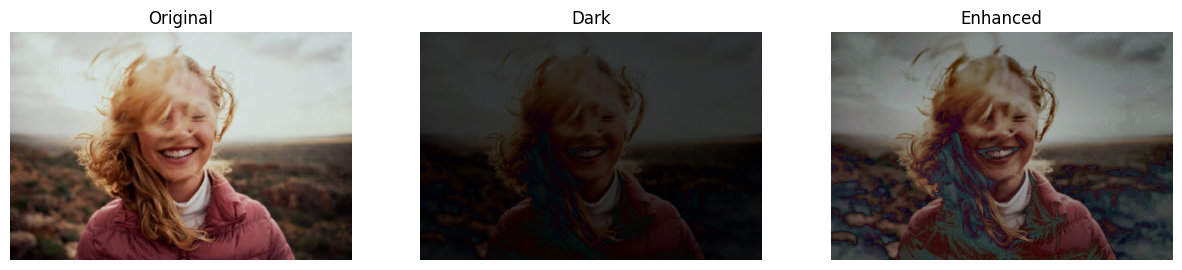

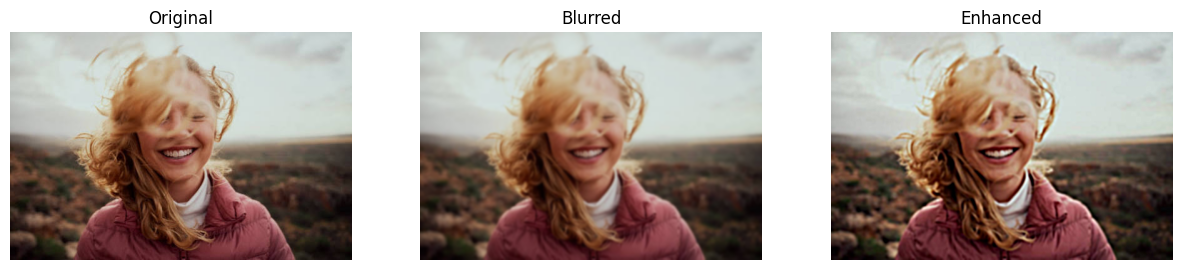

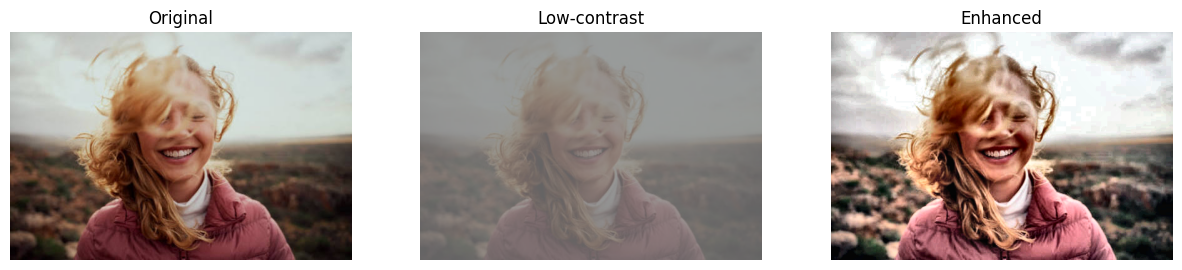

In [ ]:
INPUT_PATH = "images/input/potrait_example.jpeg"
original = cv2.imread(INPUT_PATH)

dark_img     = cv2.convertScaleAbs(original, alpha=0.30, beta=-15)
blurred_img  = cv2.GaussianBlur(original, (7, 7), 0)
low_contrast = ((original.astype(np.float32) * 0.25) + 100).astype(np.uint8)

dark_out = enhance_dark_image(dark_img)
blur_out = enhance_blurred_image(blurred_img)
lc_out   = enhance_low_contrast_v2(low_contrast)

show_images(["Original", "Dark", "Enhanced"],
            [original, dark_img, dark_out])
show_images(["Original", "Blurred", "Enhanced"],
            [original, blurred_img, blur_out])
show_images(["Original", "Low-contrast", "Enhanced"],
            [original, low_contrast, lc_out])

In [ ]:
for name, img in {
        "dark_enhanced": dark_out,
        "blur_enhanced": blur_out,
        "lc_enhanced": lc_out,
    }.items():
        cv2.imwrite(f"images/output/{name}.png", img)